### Optional question:
#### Is the fan vote share systematically biased toward the "home" label, or does it just reflect genuine quality differences?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

IN_DIR = "cleaned_data"

votes = pd.read_parquet(f"{IN_DIR}/votes.parquet")
home_rank = pd.read_parquet(f"{IN_DIR}/home_team.parquet")[["match_id", "current_rank"]].rename(
    columns={"current_rank": "home_rank"})
away_rank = pd.read_parquet(f"{IN_DIR}/away_team.parquet")[["match_id", "current_rank"]].rename(
    columns={"current_rank": "away_rank"})

In [5]:
v = votes.merge(home_rank, on="match_id", how="inner").merge(away_rank, on="match_id", how="inner")
v = v[(v["home_vote"] + v["away_vote"]) > 0].copy()   # matches with zero total votes can't be judged

v["home_vote_share"] = v["home_vote"] / (v["home_vote"] + v["away_vote"])

### Step 1: overall bias check 

In [6]:
overall_share = v["home_vote_share"].mean()
t_stat, p_value = stats.ttest_1samp(v["home_vote_share"], 0.5)

print(f"Average home vote share (all matches): {overall_share * 100:.2f}%")
print(f"One-sample t-test vs. 50%: t={t_stat:.2f}, p={p_value:.4f}")
if p_value < 0.05:
    print("-> Statistically significant deviation from 50%.")
else:
    print("-> Not statistically significant on its own.")

Average home vote share (all matches): 52.25%
One-sample t-test vs. 50%: t=8.52, p=0.0000
-> Statistically significant deviation from 50%.


### Step 2: control for actual quality using ranking

In [7]:
v_ranked = v.dropna(subset=["home_rank", "away_rank"])
v_ranked["home_is_underdog"] = v_ranked["home_rank"] > v_ranked["away_rank"]  # bigger number = worse rank

underdog_share = v_ranked.loc[v_ranked["home_is_underdog"], "home_vote_share"].mean()
favorite_share = v_ranked.loc[~v_ranked["home_is_underdog"], "home_vote_share"].mean()
n_underdog = v_ranked["home_is_underdog"].sum()
n_favorite = (~v_ranked["home_is_underdog"]).sum()

print(f"\nHome vote share WHEN home is the underdog (worse ranked): "
      f"{underdog_share * 100:.2f}% (n={n_underdog})")
print(f"Home vote share WHEN home is the favorite (better ranked): "
      f"{favorite_share * 100:.2f}% (n={n_favorite})")


Home vote share WHEN home is the underdog (worse ranked): 32.01% (n=4427)
Home vote share WHEN home is the favorite (better ranked): 69.52% (n=5206)


C:\Users\QR\AppData\Local\Temp\ipykernel_13904\2801265089.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v_ranked["home_is_underdog"] = v_ranked["home_rank"] > v_ranked["away_rank"]  # bigger number = worse rank


### The key test: is the underdog's share still above 50%?

In [8]:
underdog_data = v_ranked.loc[v_ranked["home_is_underdog"], "home_vote_share"]
t_stat2, p_value2 = stats.ttest_1samp(underdog_data, 0.5)
print(f"\nt-test: is underdog-home's vote share still above 50%? "
      f"t={t_stat2:.2f}, p={p_value2:.4f}")


t-test: is underdog-home's vote share still above 50%? t=-65.21, p=0.0000


#### =======================================================================
### Chart
#### =======================================================================

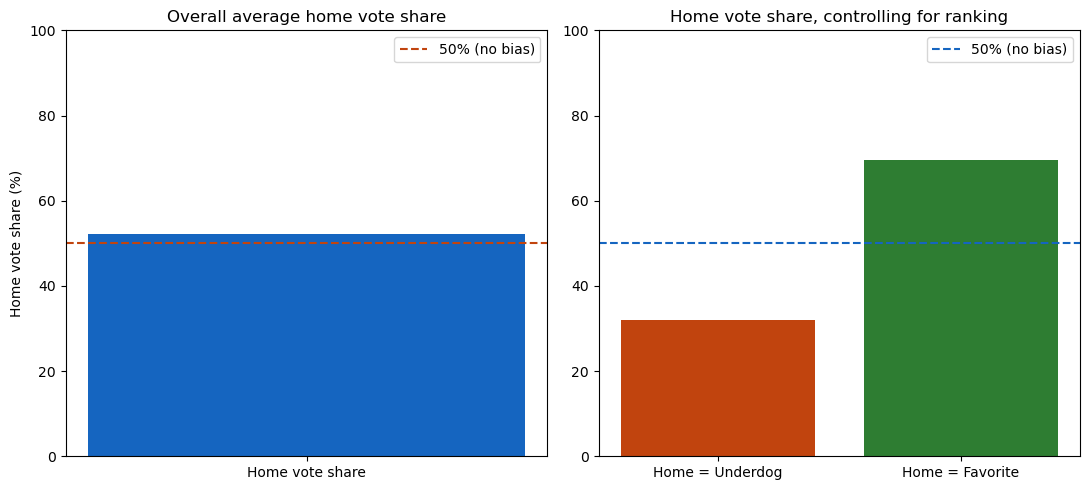

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar(["Home vote share"], [overall_share * 100], color="#1565c0")
axes[0].axhline(50, color="#c1440e", linestyle="--", label="50% (no bias)")
axes[0].set_title("Overall average home vote share")
axes[0].set_ylabel("Home vote share (%)")
axes[0].set_ylim(0, 100)
axes[0].legend()

axes[1].bar(["Home = Underdog", "Home = Favorite"],
            [underdog_share * 100, favorite_share * 100],
            color=["#c1440e", "#2e7d32"])
axes[1].axhline(50, color="#1565c0", linestyle="--", label="50% (no bias)")
axes[1].set_title("Home vote share, controlling for ranking")
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/optional_voteQ_Overall average home vote share.png', dpi=200)
plt.show()

# Question:

## Is the fan vote share systematically biased toward the "home" label, or does it just reflect genuine quality differences?

### Results:
  Overall average home vote share: 52.25% (t=8.52, p<0.0001 vs 50%) -- looks like a small but statistically significant home bias at first glance.

  BUT after controlling for actual ranking:
    Home = underdog (worse ranked):  32.01% vote share (n=4,427)
    Home = favorite (better ranked): 69.52% vote share (n=5,206)
  Both are strongly and significantly different from 50% in the direction predicted by genuine quality, not by the "home" label.

### Interpretation:
This is a Simpson's-paradox-like result. The overall 52.25% is NOT evidence of a labeling bias -- it is simply the weighted average of two very different, quality-driven behaviors: fans correctly favor whichever player is actually better ranked, regardless of the home/away label. When home happens to be the weaker player, fans correctly shift their votes toward away (only 32% for home). When home happens to be the stronger player, fans correctly favor home (69.52%).

The reason the raw overall average sits slightly above 50% is simply that, in this dataset, matches where home is the better-ranked player (n=5,206) slightly outnumber matches where home is the underdog (n=4,427) -- a sample composition effect, not a psychological bias toward the word "home".

### Conclusion:
The "labeling bias" hypothesis is REJECTED. Fan vote share tracks genuine player quality (ranking) closely, both when home is favored and when home is the underdog. This is evidence that fan votes carry real predictive information, not blind favoritism toward a display position.